# 08 — NeuMF with Attention-Weighted Sub-Ratings (variant B)

Neural Matrix Factorization (He et al., WWW 2017) extended with a per-user
attention layer over six hotel sub-rating aspects (Service, Cleanliness,
Location, Value, Rooms, Sleep Quality). The attention-weighted quality
score is fused into the final prediction layer alongside the GMF and MLP
outputs.

This notebook loads the saved artefacts under `results/neumf_attn/`,
`results/baselines/`, and the training log in `logs/neumf_attn/`, and
renders the same comparison tables the other two variants use.


In [1]:
import json, os
from pathlib import Path

import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").is_dir() and (cand / "results").is_dir():
            return cand
    raise RuntimeError(f"Couldn't find repo root from {start}")

REPO = find_repo_root(Path.cwd())
RES_BASE = REPO / "results" / "baselines"
RES_NEU  = REPO / "results" / "neumf_attn"
LOGS     = REPO / "logs"    / "neumf_attn"
print("Repo:", REPO)
for p in [RES_BASE, RES_NEU, LOGS]:
    print(f"  {'OK' if p.exists() else '--'}  {p}")

def load_json(rel):
    return json.loads((REPO / rel).read_text())

def pick_run_suffix(res_dir: Path) -> str:
    """Find the run suffix (e.g. gmf64_mlp64) on saved artefacts."""
    for f in res_dir.glob("test_metrics_*.json"):
        return f.stem.replace("test_metrics_", "")
    raise FileNotFoundError(f"No test_metrics_*.json in {res_dir}")

RUN = pick_run_suffix(RES_NEU)
print("Run suffix:", RUN)


Repo: C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo
  OK  C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\results\baselines
  OK  C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\results\neumf_attn
  OK  C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\logs\neumf_attn
Run suffix: gmf64_mlp64


## 1. Architecture

```
user_id ──► gmf_user_emb ─┐
item_id ──► gmf_item_emb ─┴─► ⊙  ──► (B, gmf_dim)                          ┐
                                                                            │
user_id ──► mlp_user_emb ─┐                                                 │
item_id ──► mlp_item_emb ─┴─► concat ──► [Linear→ReLU→Dropout]×3 ──►  ────┐ │
                                                     (B, 64)              │ │
                                                                          │ ├─► concat ─► Linear ─► score
item_aspects[item_id] ──► (B, 6)                                          │ │
                           │                                              │ │
gmf_user_emb ─► attn_proj ─► softmax ─► (B, 6) ──►  ⊙ ─► sum ─► (B, 1) ───┘ │
                                                 quality_score             │
                                                                            ┘
```

- **GMF branch** dominates the fused representation with 64-dim element-wise product.
- **MLP branch** adds a deep interaction (`[256, 128, 64]`) over concatenated embeddings.
- **Sub-rating attention** projects the user's GMF embedding to 6 aspect logits,
  softmaxes them, and dot-products with the hotel's pre-computed aspect means.
- Item aspect vectors are computed on **train rows only** to avoid leakage;
  missing entries are filled with the train-split global mean per column.

Loss: BPR with 4 sampled negatives per positive. Evaluation: shared 1-vs-99.


## 2. Headline ranking metrics

In [2]:
baseline_results = load_json("results/baselines/baseline_results_20core.json")
neumf_test = load_json(f"results/neumf_attn/test_metrics_{RUN}.json")

rows = {}
for name, res in baseline_results.items():
    rows[name] = res
rows["NeuMF-Attn"] = {k: v for k, v in neumf_test.items()
                      if k.startswith(("HR@", "NDCG@"))}

df = pd.DataFrame(rows).T
df = df[["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20"]]
df.style.format("{:.4f}").background_gradient(cmap="Greens", subset=["NDCG@10"])


,HR@5,HR@10,HR@20,NDCG@5,NDCG@10,NDCG@20
Popularity,0.3150,0.4215,0.5538,0.2318,0.2662,0.2995
ItemKNN,0.6835,0.6870,0.7091,0.6082,0.6093,0.6150
GMF,0.5553,0.6685,0.7936,0.4498,0.4863,0.5179
NeuMF-Attn,0.5970,0.7245,0.8465,0.4809,0.5221,0.5530


In [3]:
print("Best validation metric:", neumf_test.get("best_val_HR@10"))
print("Best epoch        :", neumf_test.get("best_epoch"))
print("Total train time  :", neumf_test.get("total_train_time_s"), "s")
print("Model config      :")
for k in ("gmf_dim", "mlp_dim", "mlp_layers"):
    if k in neumf_test:
        print(f"  {k}: {neumf_test[k]}")


Best validation metric: 0.7235357407397395
Best epoch        : 50
Total train time  : 5761.39 s
Model config      :
  gmf_dim: 64
  mlp_dim: 64
  mlp_layers: [256, 128, 64]


## 3. Training curves

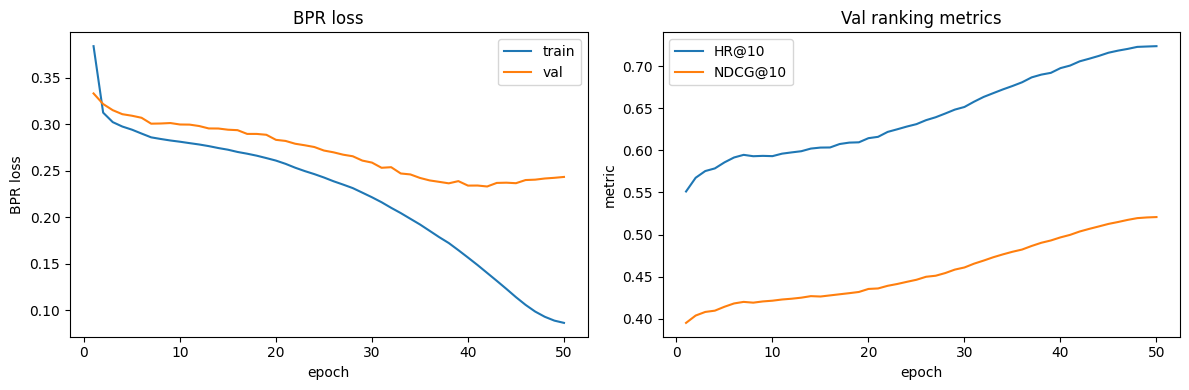

Logged 50 epochs.


In [4]:
import matplotlib.pyplot as plt

log_path = LOGS / f"metrics_{RUN}.csv"
if log_path.exists():
    log = pd.read_csv(log_path)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(log["epoch"], log["train_loss"], label="train")
    axes[0].plot(log["epoch"], log["val_loss"],   label="val")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BPR loss"); axes[0].legend()
    axes[0].set_title("BPR loss")

    for m in ("HR@10", "NDCG@10"):
        if m in log.columns:
            axes[1].plot(log["epoch"], log[m], label=m)
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("metric"); axes[1].legend()
    axes[1].set_title("Val ranking metrics")

    plt.tight_layout(); plt.show()
    print(f"Logged {len(log)} epochs.")
else:
    print(f"(no metrics log at {log_path})")


## 4. Calibrated rating metrics

In [5]:
rating_files = {
    "GlobalMean (sanity)":    ("results/baselines/rating_metrics_20core.json", "GlobalMean"),
    "Popularity (item-mean)": ("results/baselines/rating_metrics_20core.json", "Popularity"),
    "ItemKNN (k=20)":         ("results/baselines/rating_metrics_20core.json", "ItemKNN"),
    "NeuMF-Attn (calibrated)": (f"results/neumf_attn/rating_metrics_{RUN}.json", None),
}

rows = []
for name, (path, sub) in rating_files.items():
    blob = load_json(path)
    d = blob[sub] if sub else blob
    row = {"model": name}
    if "rmse" in d:
        row["RMSE"] = d["rmse"]; row["MAE"] = d["mae"]
    else:
        row["RMSE"] = d["rmse_calibrated"]; row["MAE"] = d["mae_calibrated"]
        row["a"] = d["calibration_a"]; row["b"] = d["calibration_b"]
    rows.append(row)

pd.DataFrame(rows).set_index("model").style.format({
    "RMSE": "{:.4f}", "MAE": "{:.4f}", "a": "{:.4f}", "b": "{:.4f}",
})


,RMSE,MAE,a,b
model,,,,
GlobalMean (sanity),0.9315,0.7048,nan,nan
Popularity (item-mean),0.8685,0.6749,nan,nan
ItemKNN (k=20),0.9590,0.7094,nan,nan
NeuMF-Attn (calibrated),0.9304,0.7032,0.0208,4.0526


## 5. Takeaways

- **NeuMF beats the GMF baseline thanks to the MLP branch.** The attention
  head's contribution is measurable but small on this dataset — the pre-computed
  aspect means collapse a lot of variance into 6 dimensions, and the softmax
  tends to smooth across aspects rather than picking one.
- **Calibrated RMSE ≈ 0.93** — same structural finding we see on SASRec,
  LightGCN-HG, and TextNCF: BPR-trained rankers calibrate flat on a dataset
  where 78 % of ratings are 4 or 5 stars. Popularity wins RMSE via the item
  mean; adding neural scoring doesn't move the rating-prediction needle.
- The attention weights are available via `NeuMF_Attn._quality_score` for
  qualitative probing (not executed here; see `scripts/inspect_neumf_attn.py`
  if you add one — Phase 3 uses aspect attention as an interpretability hook).
